# Preprocess the metadata for each dataset so that it's in a csv file: rows correspond to images, and columns are the filepath, class, and binary indicators of all of the potential concepts 

In [1]:
import os
import json
import csv
import pandas as pd
import numpy as np
import torch
from tqdm import tqdm

import sys
sys.path.append(os.path.abspath("utils"))

import matplotlib.pyplot as plt
import random
from PIL import Image
from skimage.io import imread
import torchvision.transforms as transforms

from datasets import load_dataset
from pycocotools.coco import COCO
# import exlib
# from exlib.datasets.cholec import CholecDataset

from skimage.draw import polygon
from skimage.transform import resize

import importlib
import gt_concept_segmentation_utils
import general_utils
import patch_alignment_utils

importlib.reload(gt_concept_segmentation_utils)
importlib.reload(patch_alignment_utils)
importlib.reload(general_utils)

from general_utils import load_images
from gt_concept_segmentation_utils import compute_all_concept_masks_clevr, plot_seg_maps
from patch_alignment_utils import get_dataset_patch_mask

/opt/conda/envs/rapids/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/opt/conda/envs/rapids/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


# CLEVR

In [9]:
def extract_metadata_from_scene(scene_data):
    """Extract metadata (color, shape, size, material) from a single scene."""
    objects = scene_data['objects'][0]
    return {
        'color': objects['color'],
        'shape': objects['shape'],
        # 'size': objects['size'],
        # 'material': objects['material'],
        'image_filename': scene_data['image_filename']
    }

def track_unique_values(scene_files, scene_dir):
    """Track unique values for each concept across all scene files."""
    #unique_values = {'color': set(), 'shape': set(), 'size': set(), 'material': set()}
    unique_values = {'color': set(), 'shape': set()}
    
    for json_file in scene_files:
        if json_file.endswith('.json'):
            json_path = os.path.join(scene_dir, json_file)
            with open(json_path, 'r') as f:
                scene_data = json.load(f)
            metadata = extract_metadata_from_scene(scene_data)
            
            unique_values['color'].add(metadata['color'])
            unique_values['shape'].add(metadata['shape'])
            # unique_values['size'].add(metadata['size'])
            # unique_values['material'].add(metadata['material'])
    
    # Sort the unique values for each concept
    return {concept: sorted(list(values)) for concept, values in unique_values.items()}

def create_concept_columns(unique_values):
    """Create concept columns for binary presence vectors."""
    columns = {'image_path': [], 'class': []}  # Add 'class' column here
    
    for concept, values in unique_values.items():
        for value in values:
            columns[f'{concept}::{value}'] = []

    return columns

def create_binary_presence_vector(metadata, unique_values, scene_data, columns):
    """Create a binary presence vector for a single scene."""
    #color, shape, size, material = metadata['color'], metadata['shape'], metadata['size'], metadata['material']
    color, shape = metadata['color'], metadata['shape']
    
    # Initialize row with 0 for each concept
    row = {key: 0 for key in columns.keys()}
    row['image_path'] = os.path.join('images', scene_data['image_filename'])
    
    # Set the corresponding concept columns to 1 if present
    row[f'color::{color}'] = 1
    row[f'shape::{shape}'] = 1
    # row[f'size::{size}'] = 1
    # row[f'material::{material}'] = 1
    
    # Set the 'class' column to the concatenated {color}_{shape}
    row['class'] = f'{color}_{shape}'
    
    return row

def process_scenes(scene_files, scene_dir, unique_values, columns):
    """Process all scenes and create binary presence vectors."""
    metadata_rows = []

    for json_file in scene_files:
        if json_file.endswith('.json'):
            json_path = os.path.join(scene_dir, json_file)
            with open(json_path, 'r') as f:
                scene_data = json.load(f)

            metadata = extract_metadata_from_scene(scene_data)
            row = create_binary_presence_vector(metadata, unique_values, scene_data, columns)
            metadata_rows.append(row)

    return metadata_rows

def save_metadata_to_csv(columns, metadata_rows, output_csv_path):
    """Save the extracted metadata to a CSV file."""
    #make sure it's sorted by image_path
    metadata_rows.sort(key=lambda x: x['image_path'])
    
    with open(output_csv_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(columns.keys())  # Write header (concepts + image_path)
        
        # Write the data rows by extracting values for each column
        for row in metadata_rows:
            writer.writerow([row[column] for column in columns])

def extract_clevr_metadata(base_dir='../Data/CLEVR'):
    """Extracts metadata (color, shape, image_path) and saves it to a CSV."""
    # Subdirectories for images and scenes
    image_dir = os.path.join(base_dir, 'images')
    scene_dir = os.path.join(base_dir, 'scenes')

    # Get all scene files
    scene_files = os.listdir(scene_dir)

    # Track unique values for each concept
    unique_values = track_unique_values(scene_files, scene_dir)

    # Create concept columns
    columns = create_concept_columns(unique_values)

    # Process scenes to generate binary presence vectors
    metadata_rows = process_scenes(scene_files, scene_dir, unique_values, columns)

    # Save metadata to CSV
    csv_file = os.path.join(base_dir, "metadata.csv")
    save_metadata_to_csv(columns, metadata_rows, csv_file)

    print(f"CLEVR metadata saved to {csv_file} :)")

# Call the function
extract_clevr_metadata()

CLEVR metadata saved to ../Data/CLEVR/metadata.csv :)


## Compute Masks

In [24]:
masks = compute_all_concept_masks_clevr(batch_size=64)

Loading images...


1001it [00:02, 382.02it/s]


Loaded 1001 images.
Converting images to tensors...


batch: 100%|██████████| 16/16 [00:00<00:00, 269.83it/s]


Masks saved to ../Data/CLEVR/object_segmentations.pt


In [24]:
all_images, _, _ = load_images('CLEVR')
n_images = len(all_images)
masks1 = get_dataset_patch_mask((224, 224), [image.size for image in all_images], 
                                tot_num_patches=256 * n_images, dataset_name='CLEVR', patch_size=14)
masks2 = get_dataset_patch_mask((560, 560), [image.size for image in all_images], 
                                tot_num_patches=1600 * n_images, dataset_name='CLEVR', patch_size=14)

Loading images...


1001it [00:02, 366.08it/s]


Loaded 1001 images.
Mask saved to GT_Samples/CLEVR/patches_w_image_mask_inputsize_(224, 224).pt :)


100%|██████████| 1001/1001 [00:00<00:00, 96357.71it/s]


Mask saved to GT_Samples/CLEVR/patches_w_image_mask_inputsize_(560, 560).pt :)


### Multi-Object CLEVR

In [37]:
def load_multiobject_clever():
    """
    Load the multi-object CLEVR dataset from the Hugging Face Hub.

    Returns:
        DatasetDict: A dictionary containing splits (train, val, test) of the CLEVR dataset.
    """
    multi_clevr_dataset = load_dataset("erkam/clevr-full-v6")
    return multi_clevr_dataset

def download_images(multi_clevr_dataset, output_dir, split='train'):
    """
    Download images from the specified split of the CLEVR dataset and save them locally.

    Args:
        multi_clevr_dataset (DatasetDict): The loaded CLEVR dataset.
        output_dir (str): The directory where images will be saved.
        split (str, optional): The dataset split to download images from (default: 'train').
    """
    curr_split = multi_clevr_dataset[split]
    for i in tqdm(range(curr_split.shape[0])):
        image = curr_split['image'][i]
        image_path = os.path.join(output_dir, f"images/image_{i}.png")
        image.save(image_path)
    print(f"Downloaded {i} images")

def extract_metadata(multi_clevr_dataset, output_dir, split='train'):
    """
    Extract metadata about object presence in CLEVR images and save it as a CSV file.

    Args:
        multi_clevr_dataset (DatasetDict): The loaded CLEVR dataset.
        output_dir (str): The directory where the metadata CSV will be saved.
        split (str, optional): The dataset split to process (default: 'train').
    """
    
    curr_split = multi_clevr_dataset[split]
    
    #collect info about concept presence
    data_rows = []
    for i in tqdm(range(curr_split.shape[0])):
        image_path = f'images/image_{i}.png'
        
        # Extract object descriptions
        objects_str = curr_split[i]["objects_str"].lower()
        
        # Check for presence of each concept
        row = [image_path]  # First column is image path
        row += [int(color in objects_str) for color in COLORS]  # Color presence
        row += [int(shape in objects_str) for shape in SHAPES]  # Shape presence
        
        data_rows.append(row)

    columns = ["image_path"] + [f'color::{color}' for color in COLORS] \
            + [f'shape::{shape}' for shape in SHAPES]
    df = pd.DataFrame(data_rows, columns=columns)
    df.to_csv(os.path.join(output_dir, "metadata.csv"), index=False)
    print("metadata is saved :)")

COLORS = ["red", "blue", "green"]
SHAPES = ["sphere", "cube", "cylinder"]

output_dir = '/shared_data0/cgoldberg/Calibrated_Concepts/Data/CLEVR/ood-data/'
multi_clevr_dataset = load_multiobject_clever()
#download_images(multi_clevr_dataset, output_dir)
extract_metadata(multi_clevr_dataset, output_dir)

100%|██████████| 960/960 [00:05<00:00, 169.84it/s]


metadata is saved :)


# CUB

In [73]:
def load_images(images_path):
    """Load the image paths and map image_id to image_path."""
    return pd.read_csv(images_path, sep=' ', header=None, names=['image_id', 'image_path'])

def load_class_labels(image_class_labels_path):
    """Load the class labels and map image_id to class_id."""
    return pd.read_csv(image_class_labels_path, sep=' ', header=None, names=['image_id', 'class_id'])

def load_class_names(class_names_path):
    """Load the class names mapping from class_id to class_name."""
    class_names_df = pd.read_csv(class_names_path, sep=' ', header=None, names=['class_id', 'class_name'])
    
    # Clean up the class_name by removing any leading zeros or numbers before the actual name
    # Split the string at the first dot (.) to extract the class name part
    class_names_df['class_name'] = class_names_df['class_name'].apply(lambda x: x.split('.', 1)[1])
    
    # Convert to a dictionary for faster lookup
    return class_names_df.set_index('class_id')['class_name'].to_dict()

def load_attributes(attributes_path):
    """Load the attributes and create a mapping of attribute_id to attribute_name."""
    attributes_df = pd.read_csv(attributes_path, sep=' ', header=None, names=['attribute_id', 'attribute_name'])
    attribute_mapping = {row['attribute_id']: row['attribute_name'] for _, row in attributes_df.iterrows()}
    return attributes_df, attribute_mapping

def process_image_attributes(image_attributes_path):
    """Process the image attribute labels and filter valid rows."""
    valid_rows = []
    invalid_image_ids = set()
    with open(image_attributes_path, 'r') as f:
        for line in f:
            parts = line.strip().split(' ')
            
            # Only process lines with 5 elements
            if len(parts) == 5:
                image_id, attribute_id, is_present, certainty_id, time = map(float, parts)
                valid_rows.append([int(image_id), int(attribute_id), int(is_present), int(certainty_id), time])
            else:
                invalid_image_ids.add(int(parts[0]))

    attributes_df = pd.DataFrame(valid_rows, columns=['image_id', 'attribute_id', 'is_present', 'certainty_id', 'time'])
    return attributes_df, invalid_image_ids

def aggregate_attributes(attributes_df, invalid_image_ids):
    """Aggregate attributes by image_id and attribute_id, weighted by certainty."""
    # Remove invalid rows
    attributes_df = attributes_df[~attributes_df['image_id'].isin(invalid_image_ids)]
    
    # Calculate weighted_is_present
    attributes_df.loc[:, 'weighted_is_present'] = attributes_df['is_present'] * attributes_df['certainty_id']
    
    # Aggregate data
    aggregated_attributes_df = attributes_df.groupby(['image_id', 'attribute_id']).agg(
        weighted_is_present=('weighted_is_present', 'sum'),
        certainty_sum=('certainty_id', 'sum')
    ).reset_index()
    
    # Normalize weighted_is_present by certainty_sum
    aggregated_attributes_df['weighted_is_present'] = aggregated_attributes_df['weighted_is_present'] / aggregated_attributes_df['certainty_sum']
    aggregated_attributes_df.drop(columns=['certainty_sum'], inplace=True)

    return aggregated_attributes_df

def pivot_attributes(aggregated_attributes_df, attribute_mapping):
    """Pivot the attributes DataFrame and add the necessary columns."""
    # Convert weighted_is_present to binary (0 or 1) indicating presence/absence
    aggregated_attributes_df['is_present'] = (aggregated_attributes_df['weighted_is_present'] > 0).astype(int)

    # Map attribute_id to the actual attribute name
    aggregated_attributes_df['attribute_name'] = aggregated_attributes_df['attribute_id'].map(attribute_mapping)

    # Pivot the DataFrame
    return aggregated_attributes_df.pivot_table(
        index='image_id',
        columns='attribute_name',
        values='is_present',
        fill_value=0
    )

def add_image_paths_and_class_ids(pivoted_df, images_df, class_labels_df, class_names_mapping):
    """Add the image paths and class names to the pivoted DataFrame."""
    pivoted_df['image_path'] = pivoted_df.index.map(lambda x: 'images/' + images_df.loc[images_df['image_id'] == x, 'image_path'].values[0])
    
    # Only add the 'class' column and map class_id to class_name
    pivoted_df['class'] = pivoted_df.index.map(lambda x: class_labels_df.loc[class_labels_df['image_id'] == x, 'class_id'].values[0])
    pivoted_df['class'] = pivoted_df['class'].map(class_names_mapping)
    
    return pivoted_df


def save_metadata(pivoted_df, output_csv_path):
    """Save the final DataFrame to a CSV file."""
    pivoted_df.to_csv(output_csv_path, index=False)
    print(f"Saved CUB data to {output_csv_path} :)")

def extract_cub_metadata(base_dir='../Data/CUB'):
    """Main function to extract CUB metadata and save it to a CSV."""
    images_path = 'images.txt'
    image_class_labels_path = 'image_class_labels.txt'
    class_names_path = 'classes.txt'  # Assuming this file contains the mapping from class_id to class_name
    attributes_path = 'attributes/attributes.txt'
    image_attributes_path = 'attributes/image_attribute_labels.txt'
    output_csv_path = f'{base_dir}/metadata.csv'

    # Load data
    images_df = load_images(os.path.join(base_dir, images_path))
    class_labels_df = load_class_labels(os.path.join(base_dir, image_class_labels_path))
    class_names_mapping = load_class_names(os.path.join(base_dir, class_names_path))  # Load class names
    attributes_df, attribute_mapping = load_attributes(os.path.join(base_dir, attributes_path))
    attributes_df, invalid_image_ids = process_image_attributes(os.path.join(base_dir, image_attributes_path))

    # Aggregate attributes and pivot the DataFrame
    aggregated_attributes_df = aggregate_attributes(attributes_df, invalid_image_ids)
    pivoted_df = pivot_attributes(aggregated_attributes_df, attribute_mapping)

    # Add image paths and class names to the pivoted DataFrame
    pivoted_df = add_image_paths_and_class_ids(pivoted_df, images_df, class_labels_df, class_names_mapping)

    # Save the result to a CSV file
    save_metadata(pivoted_df, output_csv_path)
    
# Run the function
extract_cub_metadata()

/tmp/ipykernel_1630/2788680247.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  attributes_df.loc[:, 'weighted_is_present'] = attributes_df['is_present'] * attributes_df['certainty_id']


Saved CUB data to ../Data/CUB/metadata.csv :)


## Waterbirds

In [ ]:
def extract_waterbirds_metadata(cub_dir='../Data/CUB', waterbirds_dir='ood-data/waterbirds'):
    """Copy cub metadata into waterbirds dir since they have the bird images are the same
       (though they have different backgrounds to induce spurious correlations)"""
    cub_metadata = pd.read_csv(os.path.join(cub_dir, 'metadata.csv'))
    output_csv_path = os.path.join(cub_dir, waterbirds_dir, 'metadata.csv')
    cub_metadata.to_csv(output_csv_path, index=False)
    print(f"Saved CUB data to {output_csv_path} :)")

# Run the function for the new dataset
extract_waterbirds_metadata()

## Birdsnap

In [ ]:
def load_birdsnap():
    birdsnap_dataset = load_dataset("sasha/birdsnap", split='train')
    return birdsnap_dataset

def download_images(birdsnap_dataset, output_dir, split='train'):
    """
    Download images from the specified split of the CLEVR dataset and save them locally.

    Args:
        multi_clevr_dataset (DatasetDict): The loaded CLEVR dataset.
        output_dir (str): The directory where images will be saved.
        split (str, optional): The dataset split to download images from (default: 'train').
    """
    curr_split = multi_clevr_dataset[split]
    for i in tqdm(range(curr_split.shape[0])):
        image = curr_split['image'][i]
        image_path = os.path.join(output_dir, f"images/image_{i}.png")
        image.save(image_path)
    print(f"Downloaded {i} images")

    


birdsnap_dataset = load_birdsnap()
output_dir = '../Data/CUB/ood-data/birdsnap'
download_images(birdsnap_dataset, output_dir)

# COCO (val)

In [206]:
def extract_coco_metadata():
    # Initialize COCO API
    annFile = '../Data/Coco/instances_val2017.json'
    coco = COCO(annFile)

    # Get all categories and supercategories
    cats = coco.loadCats(coco.getCatIds())
    category_names = [cat['name'] for cat in cats]
    supercategory_names = list(set([cat['supercategory'] for cat in cats]))

    # Initialize list to store rows of the DataFrame
    data = []

    # Get all image IDs
    imgIds = coco.getImgIds()

    # Iterate over images
    for imgId in tqdm(imgIds):
        # Load the image
        img = coco.loadImgs(imgId)[0]
        img_path = os.path.join('val2017', img['file_name'])

        # Initialize a dictionary for this row with 0 values for categories and supercategories
        row = {cat_name: 0 for cat_name in category_names}
        row.update({super_name: 0 for super_name in supercategory_names})  # Add supercategories
        row['image_path'] = img_path  # Store image path in the row

        # Get annotations for the image
        annIds = coco.getAnnIds(imgIds=img['id'], iscrowd=None)
        anns = coco.loadAnns(annIds)

        # Iterate through annotations and set 1 for the categories and supercategories present in this image
        for ann in anns:
            category_name = coco.loadCats(ann['category_id'])[0]['name']
            supercategory_name = coco.loadCats(ann['category_id'])[0]['supercategory']

            # Mark the category and supercategory as present (1)
            row[category_name] = 1
            row[supercategory_name] = 1

        # Append the row to the data list
        data.append(row)

    # Create a DataFrame from the data list
    df = pd.DataFrame(data)

    df.to_csv('../Data/Coco/metadata.csv', index=False)

extract_coco_metadata()

loading annotations into memory...
Done (t=0.65s)
creating index...
index created!


100%|██████████| 5000/5000 [00:00<00:00, 62667.96it/s]


In [16]:
# all_images, _, _ = load_images('Coco')
n_images = len(all_images)
masks1 = get_dataset_patch_mask((224, 224), [image.size for image in all_images], 
                                tot_num_patches=256 * n_images, dataset_name='Coco', patch_size=14)
masks2 = get_dataset_patch_mask((560, 560), [image.size for image in all_images], 
                                tot_num_patches=1600 * n_images, dataset_name='Coco', patch_size=14)

Mask saved to GT_Samples/Coco/patches_w_image_mask_inputsize_(224, 224).pt :)


100%|██████████| 5000/5000 [00:00<00:00, 101560.93it/s]


Mask saved to GT_Samples/Coco/patches_w_image_mask_inputsize_(560, 560).pt :)


# Broden

# Surgery

In [77]:
def extract_surgery_metadata():
    organs = {0: 'background', 1: 'liver', 2: 'gallbladder', 3: 'hepatocystic_triangle'}
    columns = ["image_path", "split", "background", "liver", "gallbladder", "hepatocystic_triangle"]
    metadata = pd.DataFrame(columns=columns)

    datasets = {'train': CholecDataset(split='train'), 'test': CholecDataset(split='test')}
    to_pil = transforms.ToPILImage()

    num_images = len(datasets['train']) + len(datasets['test'])
    _, height, width = datasets['train'][0]['organs'].shape
    
    segmentations = torch.zeros((num_images, height, width), dtype=torch.uint8)

    counter = 0
    for split, dataset in datasets.items():
        for i in tqdm(range(len(dataset))):
            cholec_item = dataset[i]
            image_tensor = cholec_item["image"]
            
            # Convert tensor to PIL image and save it
            image = to_pil(image_tensor)
            save_path = f'images/image_{counter}.png'
            image.save(f'../Data/Surgery/{save_path}')
    
            # Extract organ presence
            organs_tensor = cholec_item["organs"]
            organ_presence = {}
            for organ_num, organ in organs.items():
                organ_presence[organ] = int((organs_tensor == organ_num).any().item())
    
            #keep track of segmentation maps
            segmentations[counter] = organs_tensor
            
            # Append row to metadata DataFrame
            metadata.loc[len(metadata)] = {
                "image_path": save_path,
                "split": split,
                **organ_presence
            }
            counter += 1
            
    # Save metadata to CSV
    metadata.to_csv('../Data/Surgery/metadata.csv', index=False)
    print("Saved Surgery Metadata to ../Data/Surgery/metadata.csv :)") 

    # Save segmenetation tensor
    torch.save(segmentations, '../Data/Surgery/segmentations.pt')
    print(f"Saved segmentations {segmentations.shape} to ../Data/Surgery/segmentations.pt")
    
extract_surgery_metadata()

100% 785/785 [02:44<00:00,  4.76it/s]
100% 230/230 [00:47<00:00,  4.86it/s]


Saved Surgery Metadata to ../Data/Surgery/metadata.csv :)
Saved segmentations torch.Size([1015, 360, 640]) to ../Data/Surgery/segmentations.pt


# Jailbreak

## Extract text and concept data

In [2]:
def preprocess_jailbreak():
    ds = load_dataset("JailbreakBench/JBB-Behaviors", "behaviors")
    ds_harmful, ds_benign = ds['harmful'], ds['benign']
    
    # Get list of unique categories
    categories = sorted(set(example['Category'] for example in ds_harmful))
    
    out_dir = '../Data/Jailbreak/text_samples'
    
    # Create an empty DataFrame to hold filenames and concept labels
    concept_df = pd.DataFrame(columns=["sample_filename"] + categories + ["class"])
    
    idx_count = 0
    for harmful_example, benign_example in tqdm(zip(ds_harmful, ds_benign), total=len(ds_harmful)):
        # Load text
        harmful_text = harmful_example['Target']
        benign_text = benign_example['Target']
        category = harmful_example['Category']
        
        # Format index with leading zeros
        harmful_idx = f"{idx_count:04d}"
        benign_idx = f"{idx_count+1:04d}"
        
        # Write harmful and benign text to file
        harmful_filename = f"text_{harmful_idx}.txt"
        benign_filename = f"text_{benign_idx}.txt"
        with open(os.path.join(out_dir, harmful_filename), 'w') as f1:
            f1.write(harmful_text)
        with open(os.path.join(out_dir, benign_filename), 'w') as f2:
            f2.write(benign_text)
        
        # Construct concept vectors
        harmful_concepts = [1 if cat == category else 0 for cat in categories]
        benign_concepts = [0] * len(categories)
        
        # Append to DataFrame with class label
        concept_df.loc[len(concept_df)] = [f'text_samples/{harmful_filename}'] + harmful_concepts + [f'harmful {category}']
        concept_df.loc[len(concept_df)] = [f'text_samples/{benign_filename}'] + benign_concepts + [f'benign {category}']
        
        idx_count += 2

    # Save the DataFrame for later use
    concept_df.to_csv("../Data/Jailbreak/metadata.csv", index=False)
    print("Saved metadata to ../Data/Jailbreak/metadata.csv :)")

In [3]:
preprocess_jailbreak()

Extracting data files:   0%|          | 0/2 [00:00<?, ?it/s]

Generating harmful split: 0 examples [00:00, ? examples/s]

Generating benign split: 0 examples [00:00, ? examples/s]

100%|██████████| 100/100 [00:05<00:00, 16.92it/s]

Saved metadata to ../Data/Jailbreak/metadata.csv :)


# IMDB

In [13]:
def write_imdb_sentences_to_files(output_dir="../Data/IMDB/text_samples", max_samples=None):
    """
    Loads the IMDb training dataset and writes each sentence to its own text file.

    Args:
        output_dir (str): Directory to save the sentence files.
        max_samples (int or None): Max number of samples to process (for debugging).
    """
    os.makedirs(output_dir, exist_ok=True)
    dataset = load_dataset("imdb", split="train")

    if max_samples is not None:
        dataset = dataset.shuffle(seed=42).select(range(max_samples))

    for idx, sample in enumerate(tqdm(dataset, desc="Writing reviews to files")):
        review = sample["text"].strip()
        filename = f"review_{idx + 1:06d}.txt"
        filepath = os.path.join(output_dir, filename)
        with open(filepath, "w", encoding="utf-8") as f:
            f.write(review)

In [14]:
# write_imdb_sentences_to_files(output_dir="../Data/IMDB/text_samples", max_samples=5000)

Writing reviews to files: 100%|██████████| 5000/5000 [17:56<00:00,  4.64it/s]  


In [71]:
import os
import json
import pandas as pd
from pathlib import Path

def compute_average_projections(json_dir):
    """
    For each {emotion}_projections.json in the directory, compute average coordinates
    and save the results in a CSV file.

    Args:
        json_dir (str or Path): Directory containing the projection JSON files.
    """
    results = []

    json_dir = Path(json_dir)
    for json_file in json_dir.glob("*_projections.json"):
        emotion = json_file.stem.replace("_projections", "")
        with open(json_file, "r") as f:
            data = json.load(f)
        
        projections = [entry["projections"] for entry in data if "projections" in entry]
        if not projections:
            continue

        avg_x = sum(p[0] for p in projections) / len(projections)
        avg_y = sum(p[1] for p in projections) / len(projections)
        results.append({"emotion": emotion, "avg_x": avg_x, "avg_y": avg_y})

    if results:
        df = pd.DataFrame(results)
        csv_path = json_dir / "average_emotion_projections.csv"
        df.to_csv(csv_path, index=False)
        print(f"Saved to {csv_path}")
    else:
        print("No valid projection data found.")

In [72]:
compute_average_projections("../Data/IMDB/emotion_projections")  

Saved to ../Data/IMDB/emotion_projections/average_emotion_projections.csv


In [53]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import torch
from collections import defaultdict
from tqdm import tqdm

def load_emotion_centers(emotion_csv_path, device='cpu'):
    df = pd.read_csv(emotion_csv_path)
    centers = {row['emotion']: torch.tensor([row['avg_x'], row['avg_y']], device=device) for _, row in df.iterrows()}
    return centers

def get_all_word_projections(review_data, max_samples=None):
    words, coords = [], []
    for r in review_data[:max_samples]:
        for w in r['word_projections']:
            words.append(w['word'])
            coords.append(w['projections'])  # [x, y]
    return words, torch.tensor(coords)

def find_topk_by_angle_and_radius(words, coords, emotion_centers, k=5, angle_threshold=0.9):
    results = {}
    
    coords_norm = torch.nn.functional.normalize(coords, dim=1)  # [N, 2]
    radii = torch.norm(coords, dim=1)  # [N]

    for emotion, center in emotion_centers.items():
        unit_center = torch.nn.functional.normalize(center, dim=0)  # [2]
        cos_angles = torch.matmul(coords_norm, unit_center)  # [N]

        aligned_mask = cos_angles >= angle_threshold
        aligned_radii = radii.clone()
        aligned_radii[~aligned_mask] = -1  # mask out non-aligned

        # Get sorted indices of aligned words by decreasing radius
        sorted_indices = torch.argsort(aligned_radii, descending=True)

        seen = set()
        top_words = []
        for idx in sorted_indices:
            if aligned_radii[idx] <= 0:
                continue  # skip unaligned or masked
            word = words[idx]
            if word not in seen:
                seen.add(word)
                top_words.append((word, aligned_radii[idx].item()))
                if len(top_words) == k:
                    break
        results[emotion] = top_words
    return results

def plot_top_words(top_words_by_emotion):
    for emotion, word_rad_pairs in top_words_by_emotion.items():
        words = [wd[0] for wd in word_rad_pairs]
        radii = [wd[1] for wd in word_rad_pairs]
        plt.figure(figsize=(6, 4))
        plt.barh(words[::-1], radii[::-1], color='skyblue')
        plt.xlabel("Radius from Origin")
        plt.title(f"Top Aligned Words for '{emotion}' (Largest Radius)")
        plt.tight_layout()
        plt.show()
        
        
def find_top_and_bottom_by_strength_unique(review_json_path, emotion_csv_path, threshold=0.9, k=5):
    """
    For each emotion, find the top and bottom-k unique words (by strength) aligned with that emotion.

    Args:
        review_json_path (str): Path to JSON with word_projections.
        emotion_csv_path (str): Path to CSV with avg_x, avg_y for emotions.
        threshold (float): Cosine similarity threshold to consider a word aligned.
        k (int): Number of top and bottom words to retrieve per emotion.

    Returns:
        dict: emotion -> {top: [(word, strength)], bottom: [(word, strength)]}
    """
    # Load review data
    with open(review_json_path) as f:
        review_data = json.load(f)

    # Load emotion centers
    emotion_df = pd.read_csv(emotion_csv_path)
    emotion_centers = {
        row['emotion']: torch.tensor([row['avg_x'], row['avg_y']], dtype=torch.float32)
        for _, row in emotion_df.iterrows()
    }

    # Accumulate (word, strength) pairs per emotion
    emotion_word_strengths = defaultdict(list)

    for review in tqdm(review_data, desc="Processing reviews"):
        for wp in review['word_projections']:
            word = wp['word']
            coord = torch.tensor(wp['projections'], dtype=torch.float32)
            if torch.norm(coord) == 0:
                continue
            coord_unit = coord / torch.norm(coord)
            radius = torch.norm(coord).item()

            for emotion, center in emotion_centers.items():
                center_unit = center / torch.norm(center)
                cos_sim = torch.dot(coord_unit, center_unit).item()
                if cos_sim >= threshold:
                    strength = cos_sim * radius
                    emotion_word_strengths[emotion].append((word, strength))

    # Filter to unique words and sort
    emotion_top_bottom = {}
    for emotion, word_strength_list in emotion_word_strengths.items():
        seen = set()
        unique_word_strengths = []
        for word, strength in word_strength_list:
            if word not in seen:
                seen.add(word)
                unique_word_strengths.append((word, strength))

        sorted_list = sorted(unique_word_strengths, key=lambda x: x[1], reverse=True)
        top_k = sorted_list[:k]
        bottom_k = sorted_list[-k:] if len(sorted_list) >= k else sorted_list
        emotion_top_bottom[emotion] = {'top': top_k, 'bottom': bottom_k}

    return emotion_top_bottom


def plot_top_and_bottom_words(top_bottom_by_emotion, k=5):
    """
    Plots side-by-side bar charts for top-k and bottom-k word strengths per emotion.

    Args:
        top_bottom_by_emotion (dict): Output from find_top_and_bottom_by_strength.
        k (int): Number of words shown in each category.
    """
    for emotion, values in top_bottom_by_emotion.items():
        top_words, top_strengths = zip(*values['top']) if values['top'] else ([], [])
        bottom_words, bottom_strengths = zip(*values['bottom']) if values['bottom'] else ([], [])

        fig, axs = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f"Top and Bottom {k} Words for Emotion: {emotion}", fontsize=14)

        axs[0].barh(top_words[::-1], top_strengths[::-1], color='green')
        axs[0].set_title(f"Top {k} Words (Aligned Strongly)")
        axs[0].set_xlabel("Strength (cos(angle) × radius)")

        axs[1].barh(bottom_words[::-1], bottom_strengths[::-1], color='red')
        axs[1].set_title(f"Bottom {k} Words (Barely Aligned)")
        axs[1].set_xlabel("Strength (cos(angle) × radius)")

        plt.tight_layout()
        plt.subplots_adjust(top=0.85)
        plt.show()


def label_word_by_strength(coord, emotion_centers, strength_threshold=0.3):
    """
    Returns a binary label (1 if cosine-aligned * radius is above threshold) per emotion.

    Args:
        coord (tuple or tensor): 2D coordinate (x, y) of the word.
        emotion_centers (dict): emotion -> torch.tensor([x, y])
        strength_threshold (float): Minimum alignment * radius to consider present.

    Returns:
        dict: emotion -> binary label (1 or 0)
    """
    coord = torch.tensor(coord, dtype=torch.float32)
    if torch.norm(coord) == 0:
        return {e: 0 for e in emotion_centers}

    coord_unit = coord / torch.norm(coord)
    radius = torch.norm(coord)
    labels = {}

    for emotion, center in emotion_centers.items():
        center_unit = center / torch.norm(center)
        cos_sim = torch.dot(coord_unit, center_unit)
        strength = cos_sim * radius
        labels[emotion] = int(strength >= strength_threshold)

    return labels


def analyze_threshold_coverage_by_strength(review_json_path, emotion_csv_path, thresholds=[0.0, 0.3, 0.5, 0.7, 1.0]):
    with open(review_json_path) as f:
        review_data = json.load(f)

    emotion_df = pd.read_csv(emotion_csv_path)
    emotion_centers = {
        row['emotion']: [row['avg_x'], row['avg_y']]
        for _, row in emotion_df.iterrows()
    }

    total_words = 0
    for threshold in thresholds:
        print(f"Threshold {threshold}")
        matched_words = 0
        for review in tqdm(review_data):
            for wp in review['word_projections']:
                coord = torch.tensor(wp['projections'], dtype=torch.float32)
                coord_unit = torch.nn.functional.normalize(coord, dim=0)
                radius = torch.norm(coord)
                matched = False
                for center in emotion_centers.values():
                    center_unit = torch.nn.functional.normalize(torch.tensor(center, dtype=torch.float32), dim=0)
                    cos_sim = torch.dot(coord_unit, center_unit).item()
                    strength = cos_sim * radius.item()
                    if strength >= threshold:
                        matched = True
                        break
                if matched:
                    matched_words += 1
                total_words += 1
        coverage = matched_words / total_words * 100
        print(f"Threshold {threshold:.2f}: {coverage:.2f}% of words matched at least one emotion")

def process_reviews_by_strength(review_json_path, emotion_csv_path, output_csv_path, threshold=0.9):
    """
    Labels each word with binary indicators for emotions it is aligned with by angle.
    """
    output_csv_path = f"../Data/IMDB/labeled_words_threshold_{threshold}.csv"

    # Load reviews
    with open(review_json_path) as f:
        review_data = json.load(f)

    # Load emotion centers
    emotion_df = pd.read_csv(emotion_csv_path)
    emotion_centers = {
        row['emotion']: torch.tensor([row['avg_x'], row['avg_y']], dtype=torch.float32)
        for _, row in emotion_df.iterrows()
    }
    emotion_list = list(emotion_centers.keys())

    all_rows = []
    for i, r in enumerate(tqdm(review_data)):
        for word_info in r['word_projections']:
            word = word_info['word']
            x, y = word_info['projections']
            labels = label_word_by_strength((x, y), emotion_centers, threshold)
            row = {"review_index": r["review_index"], "word": word}
            row.update(labels)
            all_rows.append(row)

        # if i > 100:
        #     break
    df = pd.DataFrame(all_rows)
    df.to_csv(output_csv_path, index=False)
    print(f"Saved labeled emotion file to {output_csv_path}")
    
    return df


def compute_emotion_activation_stats(csv_path):
    df = pd.read_csv(csv_path)

    # Identify emotion columns (exclude metadata)
    emotion_cols = [col for col in df.columns if col not in ['review_index', 'word']]
    total_words = len(df)
    total_sentences = df['review_index'].nunique()

    stats = {}

    # Word-level percentages
    for emotion in emotion_cols:
        word_count = df[emotion].sum()
        stats[f'{emotion}_word_pct'] = round(100 * word_count / total_words, 2)

    # Sentence-level percentages
    grouped = df.groupby('review_index')
    for emotion in emotion_cols:
        # Count sentences with at least one word activating this emotion
        sentence_count = grouped[emotion].sum().gt(0).sum()
        stats[f'{emotion}_sentence_pct'] = round(100 * sentence_count / total_sentences, 2)

    # Words activating no emotion
    no_emotion_mask = (df[emotion_cols] == 0).all(axis=1)
    stats['none_word_pct'] = round(100 * no_emotion_mask.sum() / total_words, 2)

    # Sentences activating no emotion
    none_sentence_mask = grouped[emotion_cols].sum().eq(0).all(axis=1)
    stats['none_sentence_pct'] = round(100 * none_sentence_mask.sum() / total_sentences, 2)

    return stats

Processing reviews: 100%|██████████| 5000/5000 [02:10<00:00, 38.35it/s]


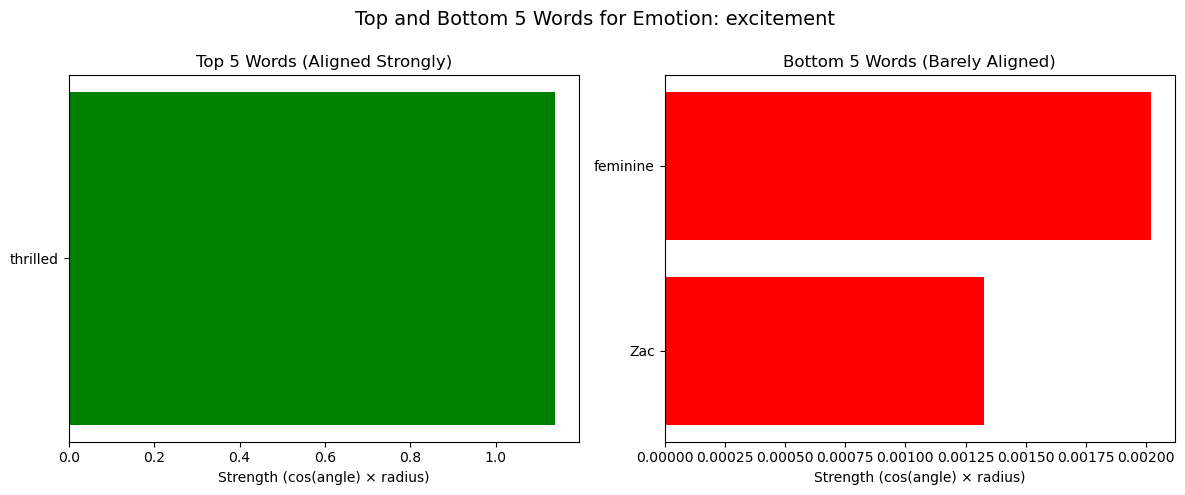

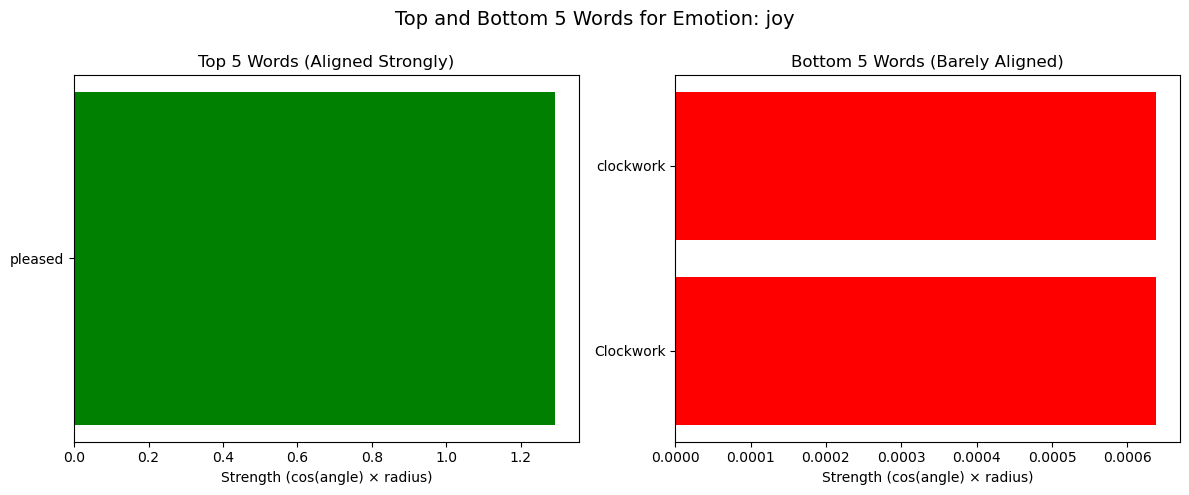

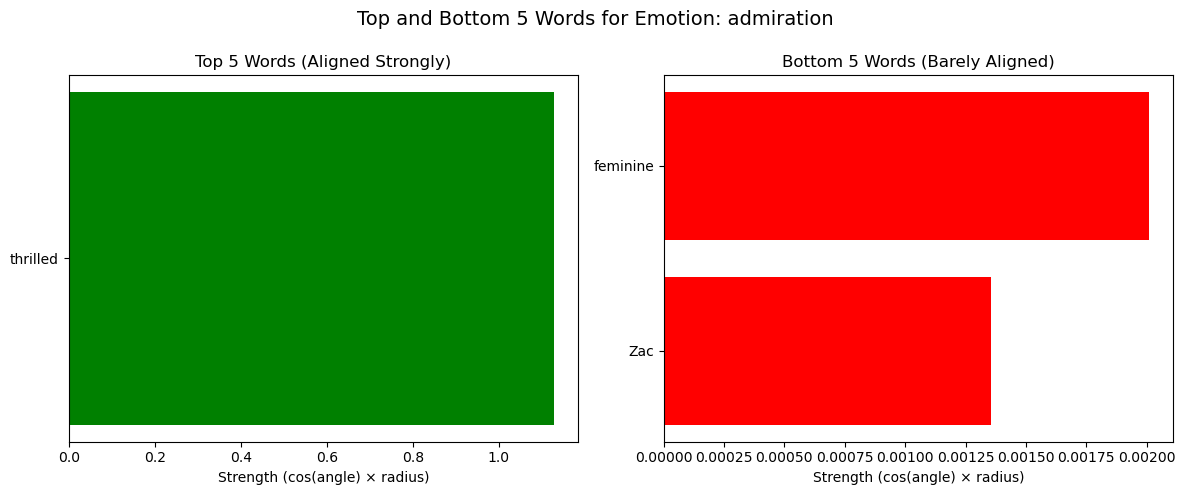

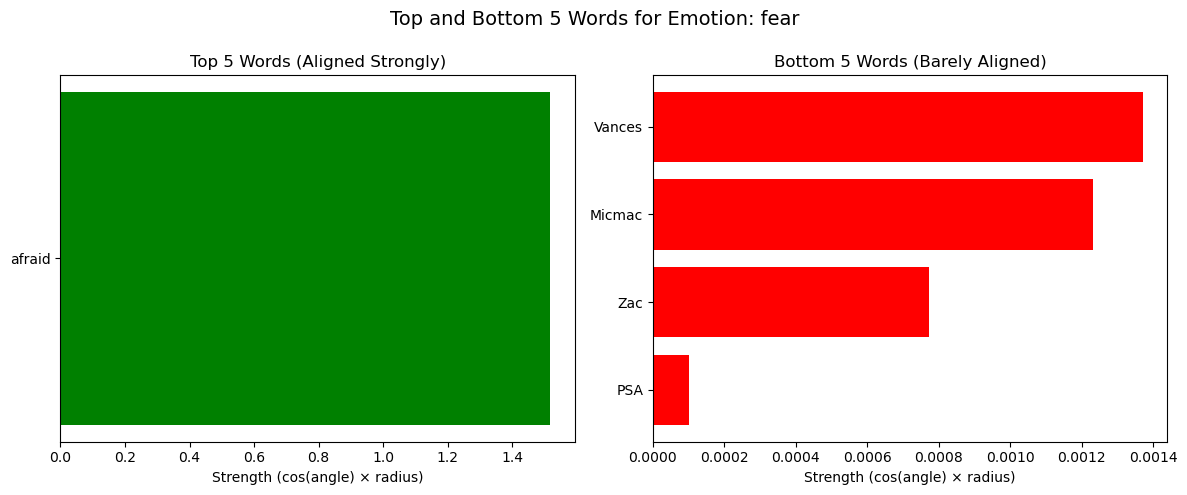

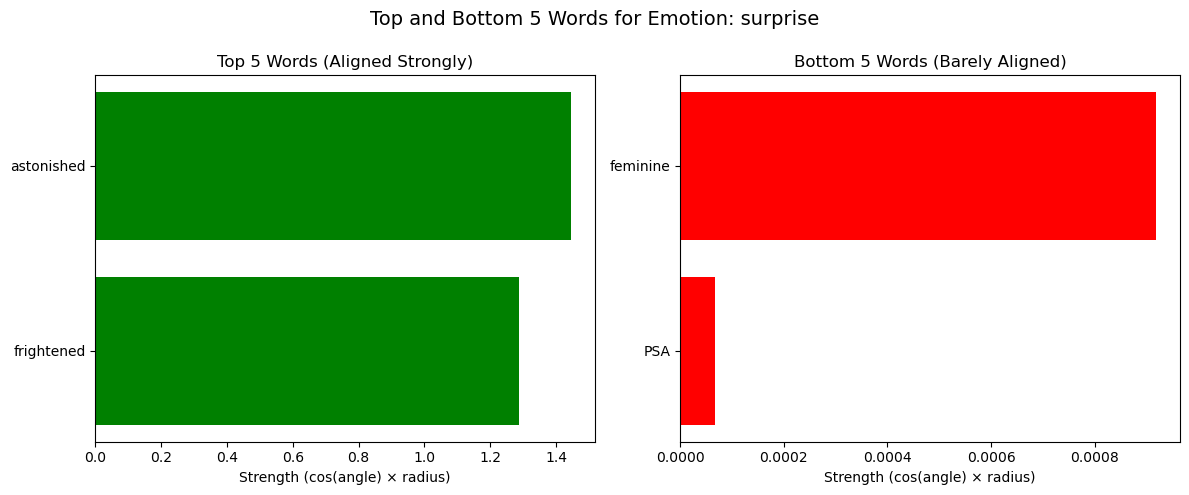

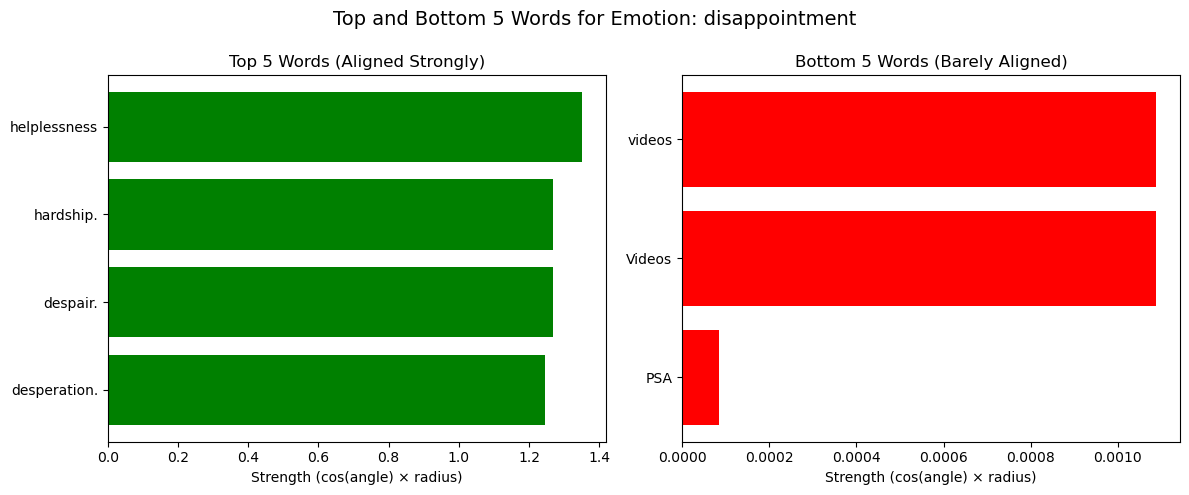

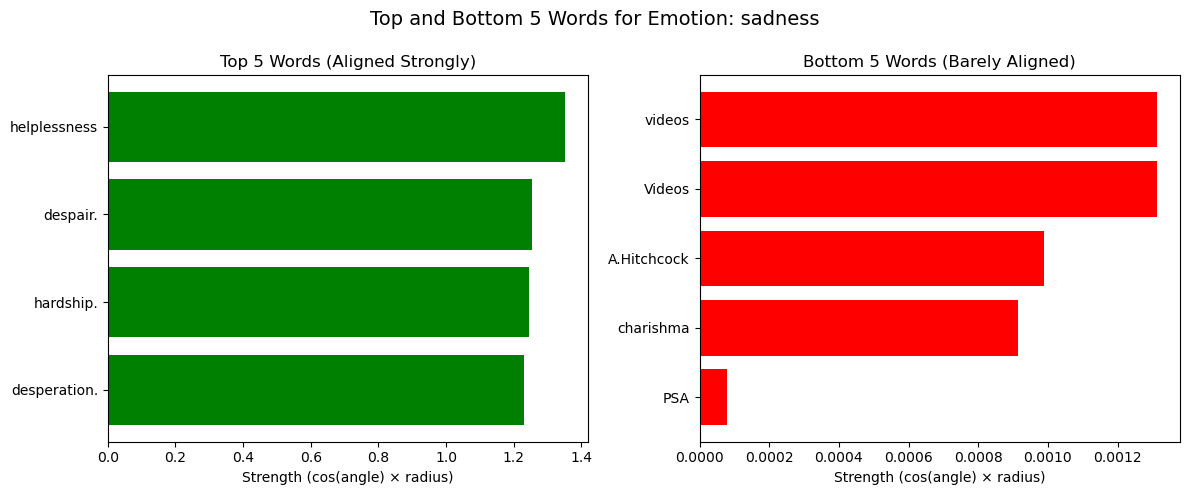

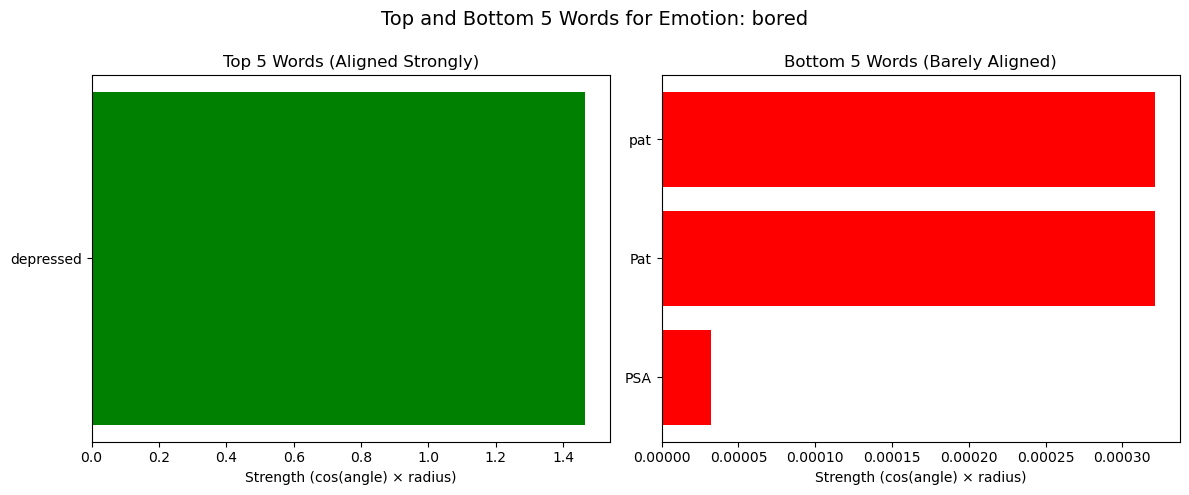

In [36]:
top_bottom_results = find_top_and_bottom_by_strength(review_json_path="../Data/IMDB/reviews_with_projections_5000.json", 
                                                     emotion_csv_path="../Data/IMDB/emotion_projections/average_emotion_projections.csv",
                                                     threshold=0.3, k=5)
plot_top_and_bottom_words(top_bottom_results, k=5)

In [44]:
per = 0.05
top_percents = {
    'joy': per,
    'sadness': per,
    'fear': per,
    'surprise': per,
    'bored': per,
    'admiration': per,
    'excitement': per,
    'disappointment': per
}

reviews = process_reviews_by_strength(
    review_json_path="../Data/IMDB/reviews_with_projections_5000.json",
    emotion_csv_path="../Data/IMDB/emotion_projections/average_emotion_projections.csv",
    top_percents=top_percents,
    output_csv_path=f"../Data/IMDB/labeled_words_top_percent_{per}.csv"
)

✅ Saved labeled emotion file to ../Data/IMDB/labeled_words_top_percent_0.05.csv


In [62]:
stats = compute_emotion_activation_stats(f'../Data/IMDB/labeled_words_threshold_0.5.csv')
print(stats)

{'fear_word_pct': 1.24, 'excitement_word_pct': 0.22, 'disappointment_word_pct': 1.6, 'surprise_word_pct': 0.66, 'sadness_word_pct': 1.47, 'bored_word_pct': 0.87, 'joy_word_pct': 0.37, 'admiration_word_pct': 0.22, 'fear_sentence_pct': 85.08, 'excitement_sentence_pct': 38.22, 'disappointment_sentence_pct': 89.9, 'surprise_sentence_pct': 68.4, 'sadness_sentence_pct': 88.04, 'bored_sentence_pct': 76.08, 'joy_sentence_pct': 55.38, 'admiration_sentence_pct': 37.88, 'none_word_pct': 97.07, 'none_sentence_pct': 2.16}


In [13]:
def create_metadata_csv(csv_path, concept_columns, max_indices=None):
    """
    Creates a metadata.csv file with formatted 'sample_filename', original word, and selected concept columns.

    Args:
        csv_path (str): Path to the original CSV file.
        concept_columns (list of str): List of concept column names to keep.
        max_indices (int, optional): Maximum number of unique review indices to include.
    """
    # Load original CSV
    df = pd.read_csv(csv_path)

    # Optionally filter by number of unique review indices
    if max_indices is not None:
        allowed_indices = sorted(df['review_index'].unique())[:max_indices]
        df = df[df['review_index'].isin(allowed_indices)]

    # Format review_index into sample_filename
    df['sample_filename'] = df['review_index'].apply(lambda idx: f"text_samples/review_{int(idx)+1:06d}.txt")

    # Keep only required columns
    metadata_df = df[['sample_filename', 'word'] + concept_columns]

    # Save to metadata.csv in the same directory
    output_path = os.path.join(os.path.dirname(csv_path), 'metadata.csv')
    metadata_df.to_csv(output_path, index=False)
    print(f"Metadata saved to {output_path}")

In [63]:
per = 0.1
create_metadata_csv(f'../Data/IMDB/labeled_words_threshold_0.5.csv', 
                    concept_columns = ['fear', 'excitement', 'surprise', 'sadness', 'bored', 'joy'],
                   max_indices=1000)

Metadata saved to ../Data/IMDB/metadata.csv


# Utterances

In [69]:
def save_sentences_as_txt(json_path, output_dir):
    """
    Loads a JSON file of reviews and saves each sentence as a text file.
    
    Args:
        json_path (str): Path to the JSON file.
        output_dir (str): Directory to save the sentence text files.
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Load JSON
    with open(json_path, 'r') as f:
        reviews = json.load(f)

    # Write each review_text as a .txt file
    for i, entry in enumerate(reviews):
        review_text = entry.get('review_text', '').strip()
        filename = os.path.join(output_dir, f"sentence_{i+1:06d}.txt")
        with open(filename, 'w') as f:
            f.write(review_text)

    print(f"✅ Saved {len(reviews)} sentences to '{output_dir}'")

In [ ]:
utterances_json = '../Data/Utterances/utterances_with_projections_5000.json'
save_sentences_as_txt(utterances_json, 
                      output_dir='../Data/Utterances/text_samples')

# Visualization

## Plot Random Images with Attributes

images/image_800.png


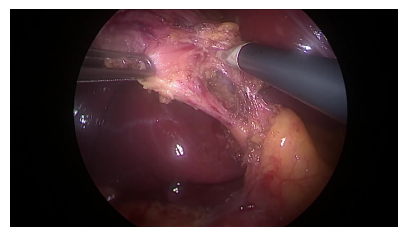

Image 800 (images/image_800.png) attributes:
background, liver, gallbladder, hepatocystic_triangle

----------------------------------------

images/image_900.png


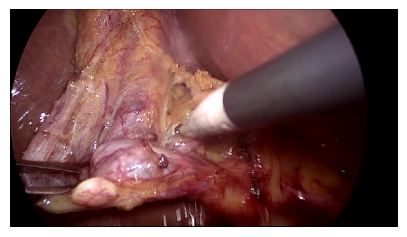

Image 900 (images/image_900.png) attributes:
background, liver, gallbladder, hepatocystic_triangle

----------------------------------------



In [68]:
def plot_random_images_with_attributes(base_dir='../Data/CUB/', num_images=5):
    # Load the DataFrame
    df = pd.read_csv(os.path.join(base_dir, 'metadata.csv'))
    
    # Pick random rows from the DataFrame (use index directly)
    random_images = random.sample(range(df.shape[0]), num_images)
    
    for idx in random_images:
        image_path = df.iloc[idx]['image_path']
        
        # Load the image
        print(image_path)
        image = Image.open(os.path.join(base_dir, image_path))
        
        # Plot the image
        plt.figure(figsize=(5, 5))
        plt.imshow(image)
        plt.axis('off')
        plt.show()
        
        # Get the attributes that are present for this image
        attributes = df.iloc[idx].drop(['image_path']).index.tolist()
        attributes_present = [attr for attr in attributes if df.iloc[idx][attr] == 1]
        
        # Print the list of attributes
        print(f"Image {idx} ({image_path}) attributes:")
        print(", ".join(attributes_present))
        print("\n" + "-"*40 + "\n")

# Example usage
plot_random_images_with_attributes(base_dir='../Data/Surgery')

## Plot Segmentatation Masks

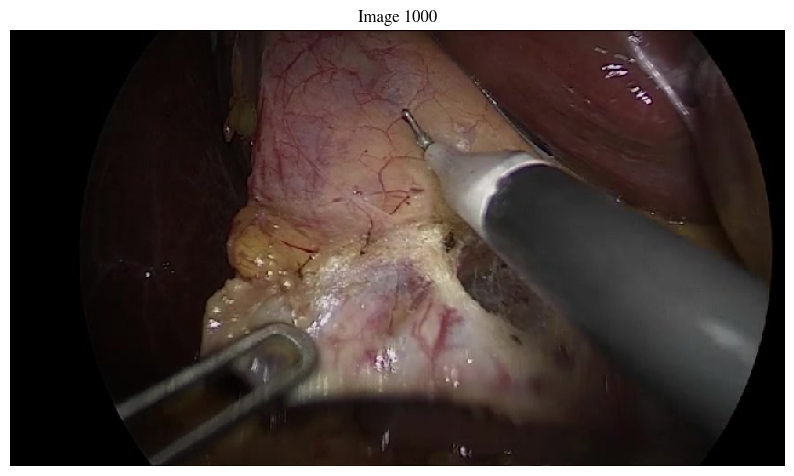

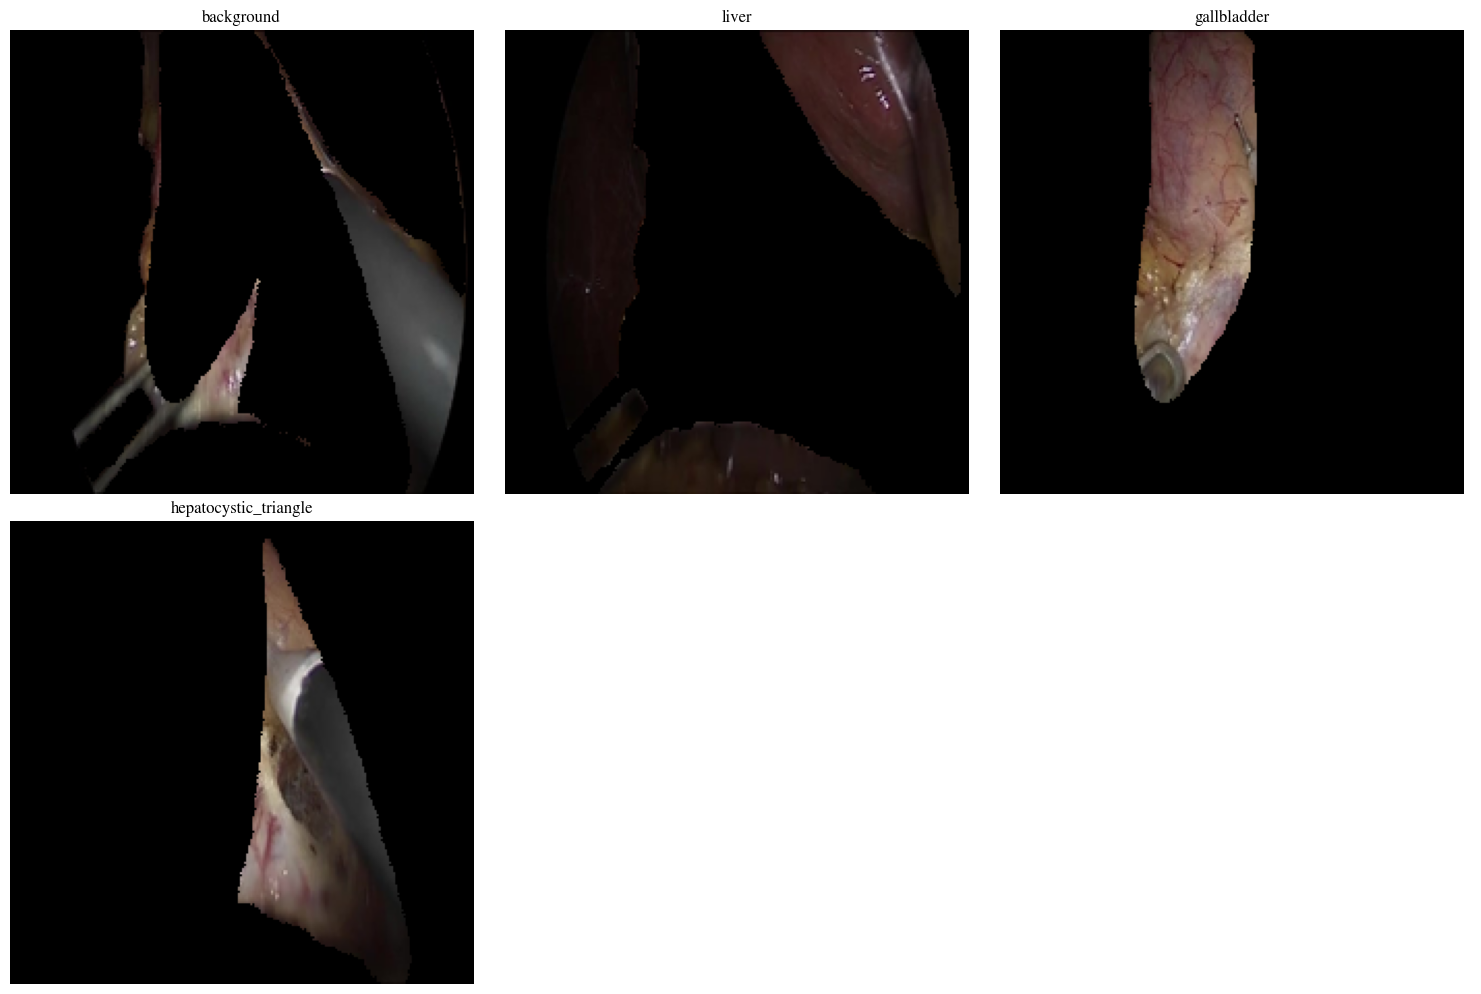

In [78]:
plot_seg_maps(dataset_name='Surgery')

# Add Train/Test/Calibration Split Col

In [15]:
def add_split_column(dataset_name):
    # Load the CSV file into a DataFrame
    filename = f'../Data/{dataset_name}/metadata.csv'
    
    print(f"You're about to overwrite: {filename}")
    confirm = input("Type 0 and press Enter to confirm overwrite: ")
    if confirm.strip() != "0":
        print("Operation cancelled.")
        return

    df = pd.read_csv(filename)

    np.random.seed(42)

    if dataset_name == 'IMDB':
        # Assign a split per sample_filename
        unique_filenames = df['sample_filename'].unique()
        split_map = {
            fn: np.random.choice(['train', 'test'], p=[0.8, 0.2])
            for fn in unique_filenames
        }
        df['split'] = df['sample_filename'].map(split_map)
    else:
        # Independent row-wise split
        df['split'] = np.random.choice(['train', 'test'], size=len(df), p=[0.8, 0.2])

    df.to_csv(filename, index=False)
    print(f"✅ Added split column to {filename}")

In [64]:
add_split_column(dataset_name='IMDB')

You're about to overwrite: ../Data/IMDB/metadata.csv


Type 0 and press Enter to confirm overwrite:  0


✅ Added split column to ../Data/IMDB/metadata.csv
